<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/hw4_csci4170ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2

## Problem Statement
In this project, I use the **Daily Delhi Climate** dataset to solve a **time-series forecasting** problem. The goal is to predict the **next day's mean temperature** using the previous several days of weather observations.

## Why sequence models are needed
This is a sequential prediction problem because temperature depends on **previous days' weather conditions**, trends, and temporal patterns. A sequence model such as a basic RNN, LSTM, or GRU is appropriate because it processes ordered observations across time and can learn dependencies between earlier and later measurements.

## Dataset source
Daily Delhi Climate dataset:  
https://www.kaggle.com/datasets/sukhmandeepsinghbrar/daily-delhi-climate

The dataset contains daily climate variables including:
- `date`
- `meantemp`
- `humidity`
- `wind_speed`
- `meanpressure`

It is commonly distributed in two CSV files:
- `DailyDelhiClimateTrain.csv`
- `DailyDelhiClimateTest.csv`

## Framework
I will use **PyTorch** to implement:
1. A basic RNN
2. An LSTM
3. A GRU

## Evaluation metric
Since this is a regression problem, I will use:
- **MSE** as the training loss
- **RMSE** as the main performance metric for validation and test sets
- **MAE** as an additional interpretable error metric

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [37]:
TRAIN_PATH = "/content/DailyDelhiClimateTrain.csv"
TEST_PATH = "/content/DailyDelhiClimateTest.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (1462, 5)
Test shape: (114, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## Initial Data Inspection
Before building sequence models, I will inspect the dataset structure, check data types, missing values, and basic summary statistics.

In [3]:
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

print(train_df.info())
print()
print(test_df.info())
print()
print(train_df.isnull().sum())
print()
print(train_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          114 non-null    datetime64[ns]
 1   meantemp      114 non-null    float64       
 2   humidity      114 non-null    float64       
 3   wind_speed    114 non-null    float64       
 4   meanpressure  114 non-null    float64       
dtypes: datetime64[ns](1

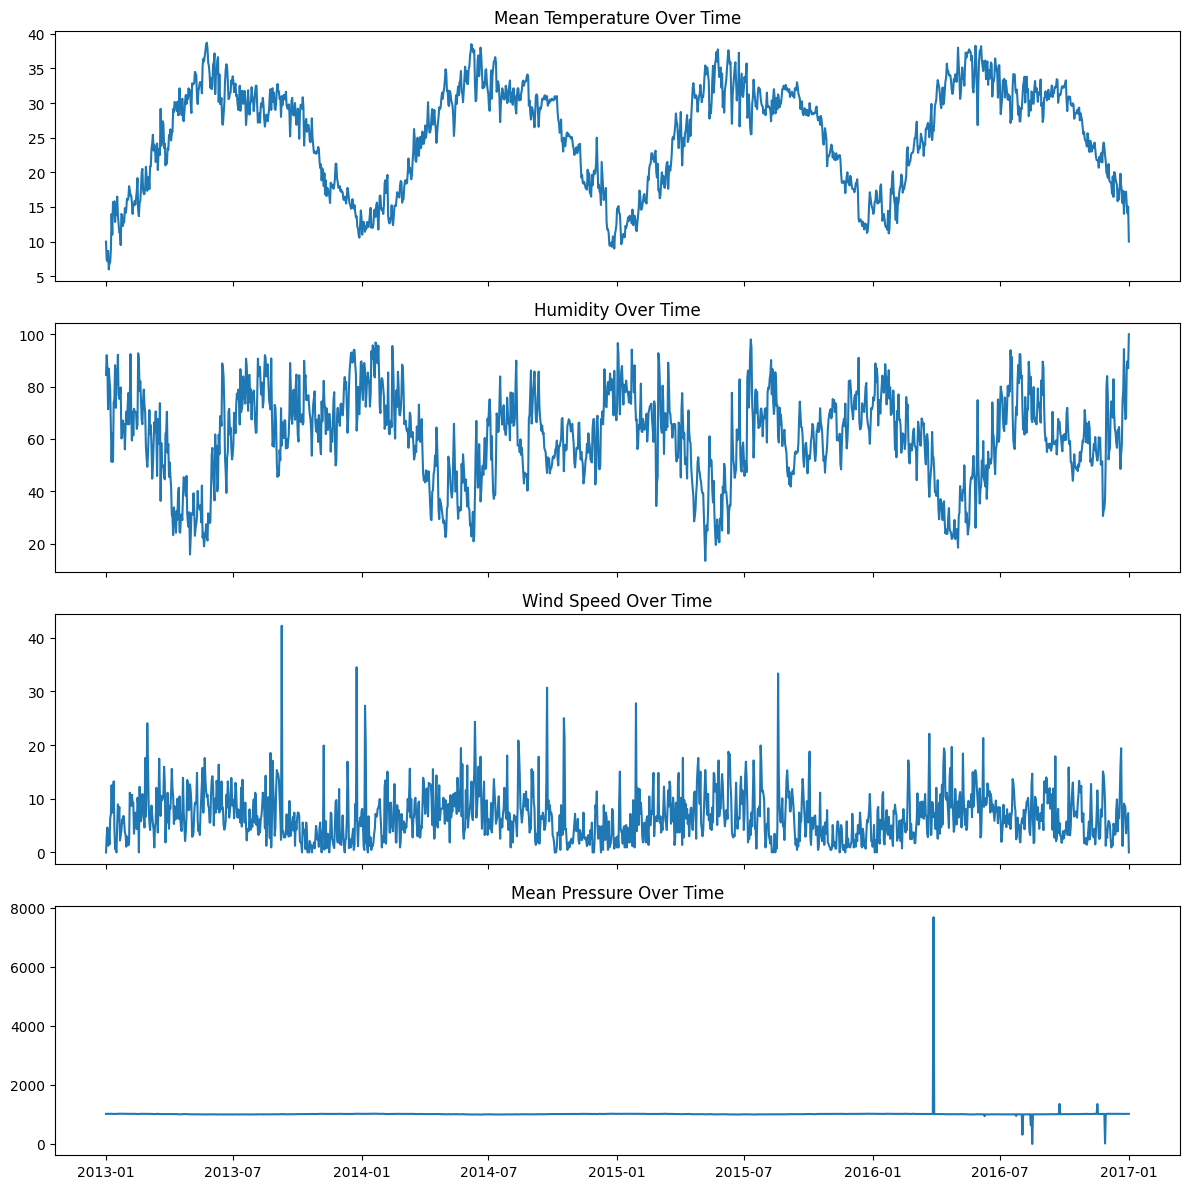

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(train_df["date"], train_df["meantemp"])
axes[0].set_title("Mean Temperature Over Time")

axes[1].plot(train_df["date"], train_df["humidity"])
axes[1].set_title("Humidity Over Time")

axes[2].plot(train_df["date"], train_df["wind_speed"])
axes[2].set_title("Wind Speed Over Time")

axes[3].plot(train_df["date"], train_df["meanpressure"])
axes[3].set_title("Mean Pressure Over Time")

plt.tight_layout()
plt.show()

## Preprocessing and Feature Engineering
I use the four climate variables as input features:
- mean temperature
- humidity
- wind speed
- mean pressure

The target is the **next day's mean temperature**.

Because sequence models are sensitive to feature scale, I standardize the input features using statistics learned from the training portion only. I also split the original training file into:
- training set
- validation set

I do not shuffle the rows, because this is time-series data and chronological order needs to be preserved.

In [5]:
feature_cols = ["meantemp", "humidity", "wind_speed", "meanpressure"]
target_col = "meantemp"

# Sort just to be safe
train_df = train_df.sort_values("date").reset_index(drop=True)
test_df = test_df.sort_values("date").reset_index(drop=True)

# Chronological split from the train CSV into train/validation
val_ratio = 0.2
split_idx = int(len(train_df) * (1 - val_ratio))

train_part = train_df.iloc[:split_idx].copy()
val_part = train_df.iloc[split_idx:].copy()

print("Train part:", train_part.shape)
print("Validation part:", val_part.shape)
print("Test part:", test_df.shape)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_part[feature_cols] = x_scaler.fit_transform(train_part[feature_cols])
val_part[feature_cols] = x_scaler.transform(val_part[feature_cols])
test_df_scaled = test_df.copy()
test_df_scaled[feature_cols] = x_scaler.transform(test_df_scaled[feature_cols])

train_part[[target_col]] = y_scaler.fit_transform(train_part[[target_col]])
val_part[[target_col]] = y_scaler.transform(val_part[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df_scaled[[target_col]])

Train part: (1169, 5)
Validation part: (293, 5)
Test part: (114, 5)


## Sequence Construction
To train an RNN-style model, we convert the continuous time series into sliding windows.

For each example:
- input = previous 30 days of multivariate climate data
- target = next day's mean temperature

This converts the raw table into supervised learning sequences.

In [6]:
SEQ_LEN = 30

def make_sequences(df, feature_cols, target_col, seq_len=30):
    data_x, data_y = [], []
    values_x = df[feature_cols].values.astype(np.float32)
    values_y = df[target_col].values.astype(np.float32)

    for i in range(len(df) - seq_len):
        x_seq = values_x[i:i+seq_len]
        y_val = values_y[i+seq_len]
        data_x.append(x_seq)
        data_y.append(y_val)

    return np.array(data_x, dtype=np.float32), np.array(data_y, dtype=np.float32).reshape(-1, 1)

X_train, y_train = make_sequences(train_part, feature_cols, target_col, SEQ_LEN)
X_val, y_val = make_sequences(val_part, feature_cols, target_col, SEQ_LEN)
X_test, y_test = make_sequences(test_df_scaled, feature_cols, target_col, SEQ_LEN)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (1139, 30, 4) y_train: (1139, 1)
X_val: (263, 30, 4) y_val: (263, 1)
X_test: (84, 30, 4) y_test: (84, 1)


In [7]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32

train_loader = DataLoader(SequenceDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(SequenceDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(SequenceDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

## Part 1: Basic RNN Model
I wil first implement a basic recurrent neural network using PyTorch.

### RNN structure
- Input size = 4 features per time step
- Hidden size = 32
- Number of recurrent layers = 1
- Output = single scalar prediction for next-day temperature

### Activation functions
- The built-in PyTorch `nn.RNN` uses **tanh** for the hidden state updates
- The output layer is a linear layer, so the output activation is effectively identity, which is appropriate for regression

In [8]:
class BasicRNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh"
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.rnn(x)             # out: (batch, seq, hidden)
        last_hidden = out[:, -1, :]       # last time step
        pred = self.fc(last_hidden)
        return pred

## Training and Evaluation Utilities
I use MSE loss during training. For reporting results, I compute:
- RMSE
- MAE

I report both validation and test performance, as required.

In [9]:
def inverse_transform_targets(y_scaled):
    return y_scaler.inverse_transform(y_scaled)

def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)

            preds.append(out.cpu().numpy())
            trues.append(yb.cpu().numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    preds_inv = inverse_transform_targets(preds)
    trues_inv = inverse_transform_targets(trues)

    mse = mean_squared_error(trues_inv, preds_inv)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(trues_inv, preds_inv)

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, rmse, mae, preds_inv, trues_inv

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_rmse": [],
        "val_mae": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_rmse, val_mae, _, _ = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_rmse"].append(val_rmse)
        history["val_mae"].append(val_mae)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_RMSE={val_rmse:.4f} | val_MAE={val_mae:.4f}")

    return history

In [10]:
input_size = len(feature_cols)

rnn_model = BasicRNNRegressor(input_size=input_size, hidden_size=32).to(device)
rnn_history = train_model(rnn_model, train_loader, val_loader, epochs=50, lr=1e-3)

Epoch   1/50 | train_loss=0.4009 | val_loss=0.1237 | val_RMSE=0.3517 | val_MAE=0.2520
Epoch  10/50 | train_loss=0.0564 | val_loss=0.0783 | val_RMSE=0.2798 | val_MAE=0.2125
Epoch  20/50 | train_loss=0.0494 | val_loss=0.0719 | val_RMSE=0.2681 | val_MAE=0.2029
Epoch  30/50 | train_loss=0.0468 | val_loss=0.0708 | val_RMSE=0.2660 | val_MAE=0.1997
Epoch  40/50 | train_loss=0.0451 | val_loss=0.0695 | val_RMSE=0.2635 | val_MAE=0.1979
Epoch  50/50 | train_loss=0.0437 | val_loss=0.0684 | val_RMSE=0.2615 | val_MAE=0.1979


## Performance Visualization
The assignment requires visualization of model performance. I will plot the training and validation loss over epochs.

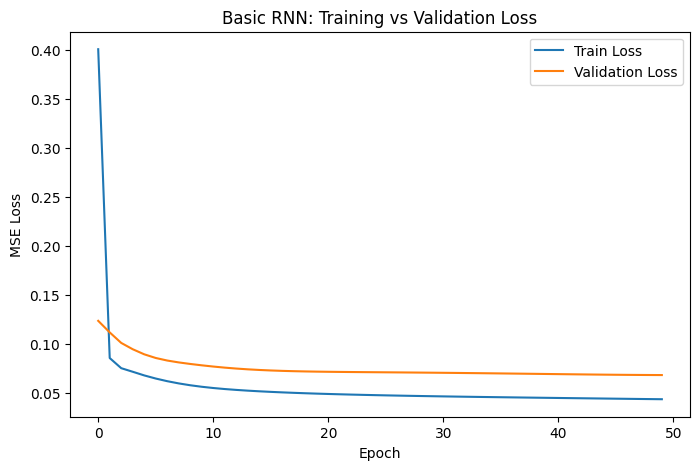

In [11]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()

plot_history(rnn_history, "Basic RNN: Training vs Validation Loss")

In [12]:
criterion = nn.MSELoss()

rnn_val_loss, rnn_val_rmse, rnn_val_mae, rnn_val_preds, rnn_val_true = evaluate_model(rnn_model, val_loader, criterion)
rnn_test_loss, rnn_test_rmse, rnn_test_mae, rnn_test_preds, rnn_test_true = evaluate_model(rnn_model, test_loader, criterion)

print("Basic RNN Validation RMSE:", rnn_val_rmse)
print("Basic RNN Validation MAE :", rnn_val_mae)
print("Basic RNN Test RMSE      :", rnn_test_rmse)
print("Basic RNN Test MAE       :", rnn_test_mae)

Basic RNN Validation RMSE: 0.26145308091611175
Basic RNN Validation MAE : 0.19789090752601624
Basic RNN Test RMSE      : 0.21060690758252645
Basic RNN Test MAE       : 0.16603292524814606


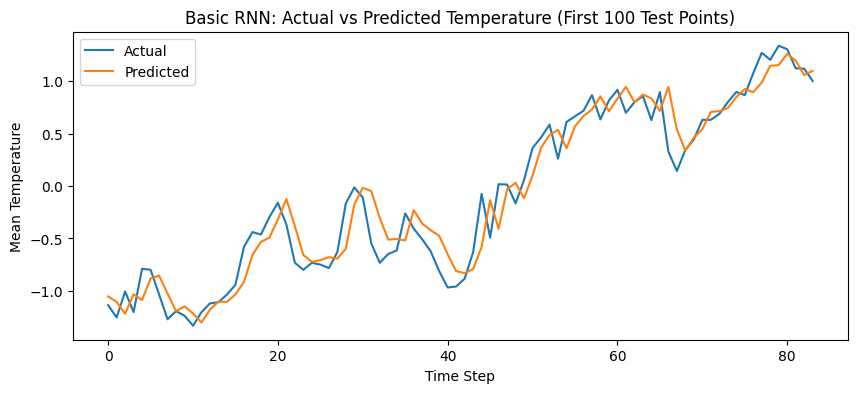

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_test_true[:100], label="Actual")
plt.plot(rnn_test_preds[:100], label="Predicted")
plt.title("Basic RNN: Actual vs Predicted Temperature (First 100 Test Points)")
plt.xlabel("Time Step")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

## Part 2: LSTM and GRU Models
I now replace the basic RNN cell with:
1. an LSTM
2. a GRU

This allows comparison of three sequence model families.

### Expected difference
A basic RNN can struggle with longer dependencies because repeated recurrence may lead to unstable gradients. LSTM and GRU introduce gating mechanisms that help preserve or discard information more effectively across time. As a result, they often train more stably and achieve lower forecasting error.

In [14]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden)
        return pred

class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden)
        return pred

## Activation Functions in LSTM and GRU
For the LSTM and GRU implementations, the recurrent units internally use gated operations with nonlinear activations. In practice:
- LSTM and GRU use sigmoid-based gates to control information flow
- candidate state updates use tanh-like nonlinearities
- the final output layer remains linear because the task is regression

In [15]:
lstm_model = LSTMRegressor(input_size=input_size, hidden_size=32).to(device)
lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=50, lr=1e-3)

gru_model = GRURegressor(input_size=input_size, hidden_size=32).to(device)
gru_history = train_model(gru_model, train_loader, val_loader, epochs=50, lr=1e-3)

Epoch   1/50 | train_loss=0.8460 | val_loss=0.7323 | val_RMSE=0.8557 | val_MAE=0.7746
Epoch  10/50 | train_loss=0.0733 | val_loss=0.1013 | val_RMSE=0.3182 | val_MAE=0.2412
Epoch  20/50 | train_loss=0.0574 | val_loss=0.0910 | val_RMSE=0.3017 | val_MAE=0.2293
Epoch  30/50 | train_loss=0.0501 | val_loss=0.0798 | val_RMSE=0.2825 | val_MAE=0.2150
Epoch  40/50 | train_loss=0.0472 | val_loss=0.0739 | val_RMSE=0.2719 | val_MAE=0.2089
Epoch  50/50 | train_loss=0.0458 | val_loss=0.0700 | val_RMSE=0.2646 | val_MAE=0.2048
Epoch   1/50 | train_loss=0.8296 | val_loss=0.6471 | val_RMSE=0.8044 | val_MAE=0.7171
Epoch  10/50 | train_loss=0.0627 | val_loss=0.0802 | val_RMSE=0.2832 | val_MAE=0.2203
Epoch  20/50 | train_loss=0.0508 | val_loss=0.0657 | val_RMSE=0.2563 | val_MAE=0.1974
Epoch  30/50 | train_loss=0.0464 | val_loss=0.0586 | val_RMSE=0.2421 | val_MAE=0.1876
Epoch  40/50 | train_loss=0.0446 | val_loss=0.0552 | val_RMSE=0.2350 | val_MAE=0.1827
Epoch  50/50 | train_loss=0.0434 | val_loss=0.0546 | v

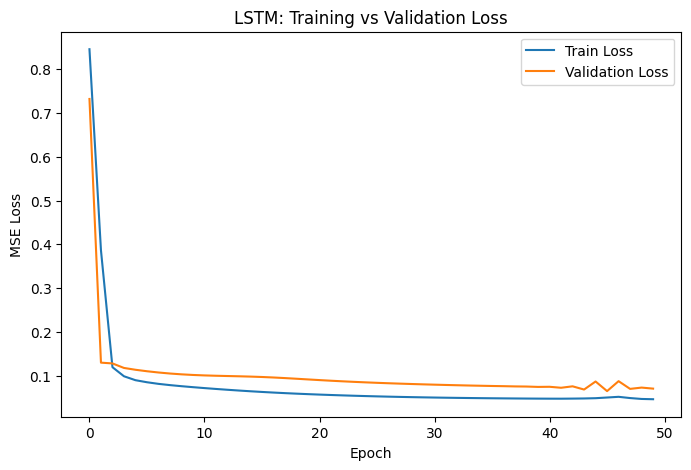

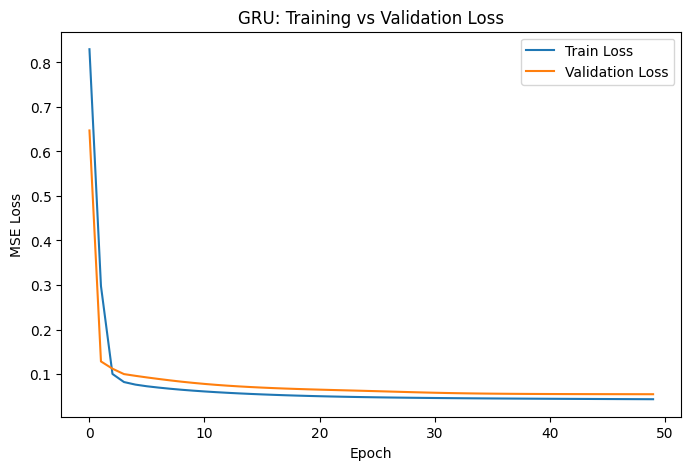

In [16]:
plot_history(lstm_history, "LSTM: Training vs Validation Loss")
plot_history(gru_history, "GRU: Training vs Validation Loss")

In [17]:
lstm_val_loss, lstm_val_rmse, lstm_val_mae, lstm_val_preds, lstm_val_true = evaluate_model(lstm_model, val_loader, criterion)
lstm_test_loss, lstm_test_rmse, lstm_test_mae, lstm_test_preds, lstm_test_true = evaluate_model(lstm_model, test_loader, criterion)

gru_val_loss, gru_val_rmse, gru_val_mae, gru_val_preds, gru_val_true = evaluate_model(gru_model, val_loader, criterion)
gru_test_loss, gru_test_rmse, gru_test_mae, gru_test_preds, gru_test_true = evaluate_model(gru_model, test_loader, criterion)

results = pd.DataFrame({
    "Model": ["Basic RNN", "LSTM", "GRU"],
    "Validation RMSE": [rnn_val_rmse, lstm_val_rmse, gru_val_rmse],
    "Validation MAE": [rnn_val_mae, lstm_val_mae, gru_val_mae],
    "Test RMSE": [rnn_test_rmse, lstm_test_rmse, gru_test_rmse],
    "Test MAE": [rnn_test_mae, lstm_test_mae, gru_test_mae]
})

results

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Basic RNN,0.261453,0.197891,0.210607,0.166033
1,LSTM,0.264637,0.204817,0.249606,0.205576
2,GRU,0.233771,0.182266,0.210681,0.169928


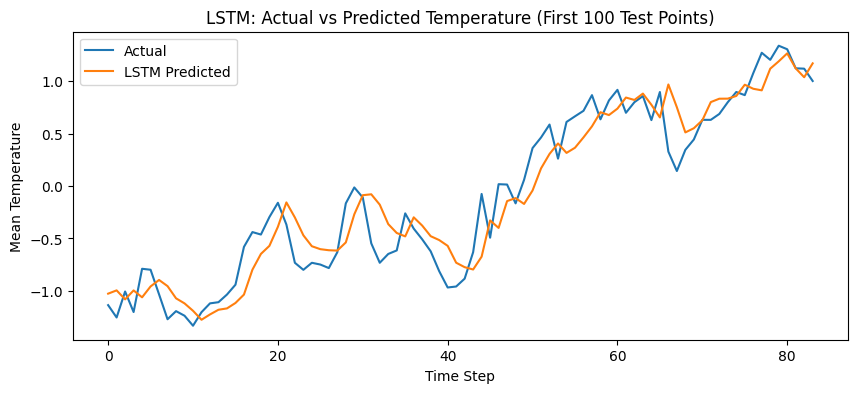

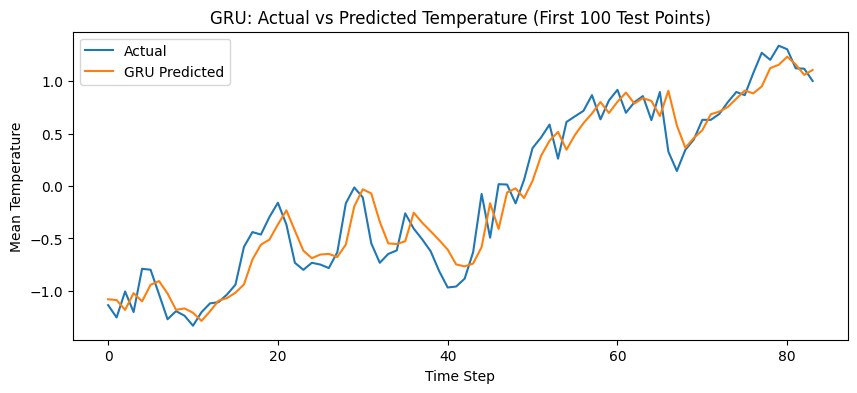

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(lstm_test_true[:100], label="Actual")
plt.plot(lstm_test_preds[:100], label="LSTM Predicted")
plt.title("LSTM: Actual vs Predicted Temperature (First 100 Test Points)")
plt.xlabel("Time Step")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(gru_test_true[:100], label="Actual")
plt.plot(gru_test_preds[:100], label="GRU Predicted")
plt.title("GRU: Actual vs Predicted Temperature (First 100 Test Points)")
plt.xlabel("Time Step")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

## Part 2 Discussion
After training all three models, I compare their validation and test performance.

### Major differences to look for
- The **basic RNN** may train, but it often performs worse because it has more difficulty preserving useful information across longer sequences.
- The **LSTM** often performs better because its memory cell and gates help it retain important long-term patterns.
- The **GRU** often performs similarly to the LSTM, while using a somewhat simpler gating structure.

### Why these differences exist
The main reason is the way the models handle temporal dependencies:
- A basic RNN repeatedly transforms the hidden state and may lose earlier information.
- LSTM uses explicit memory and gating, which helps with long-range information flow.
- GRU also uses gating, but with fewer components than LSTM, so it can sometimes train faster while still handling sequential dependencies well.

## Part 3: Can a Traditional Feed-Forward Network Solve the Same Problem?
A traditional feed-forward network can be used for this problem if the time-series data is first converted into fixed-size input features.

For example, I could take the previous 30 days of climate measurements, flatten them into one long feature vector, and use that as input to a multilayer perceptron. In that sense, the answer is yes, a feed-forward network can solve the problem.

However, sequence models are a more natural fit because they preserve the temporal order directly and are designed to model dependencies across time steps. A feed-forward network does not explicitly model recurrence or memory, so it relies entirely on the manually chosen window representation. Therefore, while a feed-forward network can work, RNN/LSTM/GRU models are usually more appropriate for sequential forecasting tasks.

# Task 3: Word Embeddings, Similarity, and Dissimilarity Analysis


## Embedding Choice
I use **GloVe embeddings** through the `gensim` library, specifically `glove-wiki-gigaword-100`.

## Why I chose GloVe
I chose GloVe over Word2Vec, FastText, and BERT for the following reasons:

- **GloVe** provides dense fixed word vectors trained on global word co-occurrence statistics, making it strong for general semantic similarity tasks.
- **Word2Vec** is also strong, but GloVe is similarly effective and is very easy to load from Gensim in a compact format.
- **FastText** has an advantage for out-of-vocabulary words because it uses subword information, but its pretrained models are often larger and slightly less convenient for a lightweight notebook assignment.
- **BERT embeddings** are contextual rather than static. They are powerful, but they are heavier, slower, and more complex than needed for this assignment, especially when the goal is comparing standalone word vectors.

For this assignment, GloVe is a practical balance of:
- semantic quality
- ease of loading
- efficiency
- interpretability

## Reference
Pennington, J., Socher, R., & Manning, C. D. (2014). *GloVe: Global Vectors for Word Representation*. EMNLP.

In [ ]:
!pip install gensim scikit-learn seaborn

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

import gensim.downloader as api

## Loading Pre-trained Embeddings Efficiently
I load the pre-trained `glove-wiki-gigaword-100` vectors using Gensim. This model contains 100-dimensional vectors for a large vocabulary of English words

In [23]:
# Load pretrained GloVe embeddings
model = api.load("glove-wiki-gigaword-100")

print("Embedding dimension:", model.vector_size)
print("Vocabulary size:", len(model.key_to_index))

Embedding dimension: 100
Vocabulary size: 400000


## Utility Functions for Word Lookup and OOV Handling
This section defines helper functions for:
- checking whether a word exists in the vocabulary
- retrieving embeddings
- handling out-of-vocabulary (OOV) cases
- suggesting approximations when an exact embedding is unavailable

Since GloVe is a static embedding model, truly unseen words do not have embeddings. In those cases, possible approximations include:
- lowercase normalization
- stripping punctuation
- splitting compounds
- using the average of known subwords
- switching to FastText, which supports subword-based embeddings

In [25]:
def normalize_word(word):
    return word.strip().lower()

def in_vocab(word, model):
    return normalize_word(word) in model.key_to_index

def get_embedding(word, model):
    w = normalize_word(word)
    if w in model.key_to_index:
        return model[w]
    return None

def approximate_oov(word, model):
    """
    Try simple approximations for OOV words.
    Returns:
        approx_vector, method_used
    """
    w = normalize_word(word)

    # 1. lowercase already handled
    if w in model.key_to_index:
        return model[w], "exact match after normalization"

    # 2. split on hyphen or underscore
    for sep in ["-", "_", " "]:
        if sep in w:
            parts = [p for p in w.split(sep) if p in model.key_to_index]
            if len(parts) > 0:
                vec = np.mean([model[p] for p in parts], axis=0)
                return vec, f"average of known parts split by '{sep}'"

    # 3. naive prefix/suffix chunking
    chunks = []
    for i in range(3, len(w) - 2):
        left = w[:i]
        right = w[i:]
        if left in model.key_to_index:
            chunks.append(model[left])
        if right in model.key_to_index:
            chunks.append(model[right])

    if len(chunks) > 0:
        vec = np.mean(chunks, axis=0)
        return vec, "average of known prefix/suffix chunks"

    return None, "no approximation found"

def print_embedding(word, model, max_values=10):
    vec = get_embedding(word, model)
    if vec is not None:
        print(f"Word: {word}")
        print(f"In vocabulary: yes")
        print(f"Embedding shape: {vec.shape}")
        print(f"First {max_values} values: {vec[:max_values]}")
    else:
        approx_vec, method = approximate_oov(word, model)
        print(f"Word: {word}")
        print("In vocabulary: no")
        print(f"Approximation method: {method}")
        if approx_vec is not None:
            print(f"Approximate embedding shape: {approx_vec.shape}")
            print(f"First {max_values} values: {approx_vec[:max_values]}")
        else:
            print("No approximate embedding available.")
            print("Suggested alternatives:")
            print("- Try lowercase or simpler spelling")
            print("- Split compounds into known words")
            print("- Use FastText for subword-based OOV handling")

## Dynamic User Input for Two Words
This section allows the user to enter two words and display their embeddings. If a word is out of vocabulary, the notebook attempts a simple approximation and explains how better approximations could be obtained.

In [26]:
word1 = input("Enter first word: ")
word2 = input("Enter second word: ")

print_embedding(word1, model)
print()
print_embedding(word2, model)

Enter first word: coat
Enter second word: rope
Word: coat
In vocabulary: yes
Embedding shape: (100,)
First 10 values: [-0.43847   0.18503  -0.086006 -0.3658    0.13956   0.7672    0.23088
  0.48014  -0.93015   0.76033 ]

Word: rope
In vocabulary: yes
Embedding shape: (100,)
First 10 values: [ 0.10258  -0.14949  -0.47717  -0.71575  -0.078966 -0.44383  -0.66539
  0.41627  -0.40395  -0.072524]


## Part 2: Cosine Similarity Computation

### Why cosine similarity is useful
Cosine similarity measures the angle between two vectors rather than their raw magnitude. This is useful in embedding space because semantically similar words often point in similar directions even if their vector lengths differ.

Cosine similarity is especially common in NLP because:
- it is scale-insensitive
- it captures directional similarity
- it works well for semantic relationships in dense embedding spaces

In [27]:
def get_best_available_vector(word, model):
    vec = get_embedding(word, model)
    if vec is not None:
        return vec, "exact"
    approx_vec, method = approximate_oov(word, model)
    return approx_vec, method

def cosine_sim_words(word_a, word_b, model):
    vec_a, method_a = get_best_available_vector(word_a, model)
    vec_b, method_b = get_best_available_vector(word_b, model)

    if vec_a is None or vec_b is None:
        return None, method_a, method_b

    sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
    return float(sim), method_a, method_b

In [28]:
sim, m1, m2 = cosine_sim_words(word1, word2, model)

print(f"Word 1: {word1} ({m1})")
print(f"Word 2: {word2} ({m2})")

if sim is not None:
    print("Cosine similarity:", sim)
else:
    print("Could not compute similarity because one or both words had no usable embedding.")

Word 1: coat (exact)
Word 2: rope (exact)
Cosine similarity: 0.4292638897895813


In [29]:
def batch_cosine_similarity(word_pairs, model):
    rows = []
    for w1, w2 in word_pairs:
        sim, m1, m2 = cosine_sim_words(w1, w2, model)
        rows.append({
            "word_1": w1,
            "word_2": w2,
            "cosine_similarity": sim,
            "word_1_status": m1,
            "word_2_status": m2
        })
    return pd.DataFrame(rows)

example_pairs = [
    ("cat", "dog"),
    ("cat", "lion"),
    ("cat", "table"),
    ("king", "queen"),
    ("car", "automobile"),
    ("happy", "sad")
]

batch_results = batch_cosine_similarity(example_pairs, model)
batch_results

,word_1,word_2,cosine_similarity,word_1_status,word_2_status
0,cat,dog,0.879808,exact,exact
1,cat,lion,0.595551,exact,exact
2,cat,table,0.310081,exact,exact
3,king,queen,0.750769,exact,exact
4,car,automobile,0.683194,exact,exact
5,happy,sad,0.680114,exact,exact


## 2D Visualization of Word Clusters
To visualize similarity relationships, I will project high-dimensional word vectors into 2D using PCA. Similar words should cluster closer together, while dissimilar words should appear farther apart.

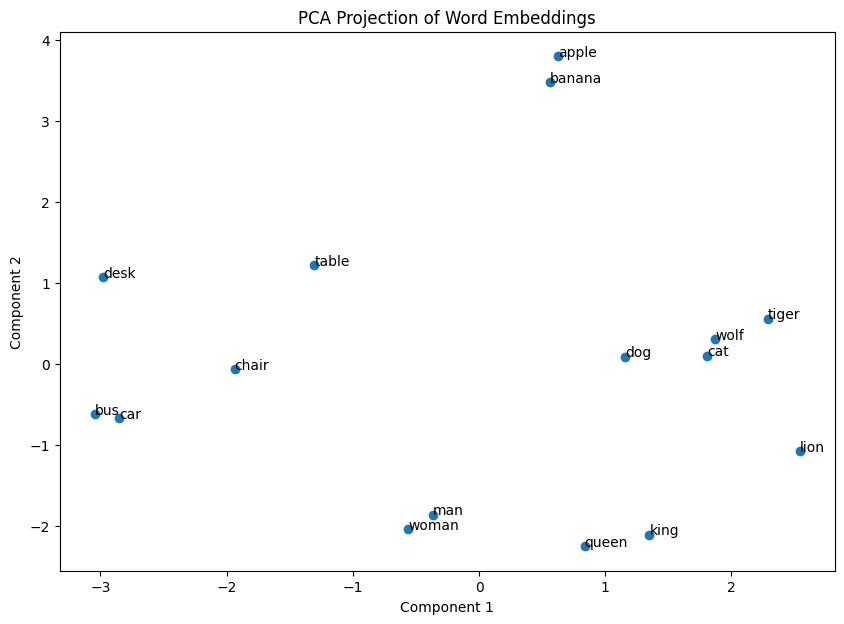

In [30]:
def plot_word_scatter(words, model, method="pca"):
    valid_words = []
    vectors = []

    for w in words:
        vec, status = get_best_available_vector(w, model)
        if vec is not None:
            valid_words.append(w)
            vectors.append(vec)

    vectors = np.array(vectors)

    if len(valid_words) < 2:
        print("Need at least two valid words to plot.")
        return

    if method.lower() == "tsne":
        reducer = TSNE(n_components=2, random_state=42, perplexity=min(5, len(valid_words)-1))
        reduced = reducer.fit_transform(vectors)
        title = "t-SNE Projection of Word Embeddings"
    else:
        reducer = PCA(n_components=2)
        reduced = reducer.fit_transform(vectors)
        title = "PCA Projection of Word Embeddings"

    plt.figure(figsize=(10, 7))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, w in enumerate(valid_words):
        plt.annotate(w, (reduced[i, 0], reduced[i, 1]))

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

word_list = [
    "cat", "dog", "lion", "tiger", "wolf",
    "table", "chair", "desk", "car", "bus",
    "king", "queen", "man", "woman", "apple", "banana"
]

plot_word_scatter(word_list, model, method="pca")

## Part 3: Designing a Novel Dissimilarity Metric

### Motivation
Cosine similarity only captures angular similarity between vectors. Two words may have similar direction but still differ in magnitude or in absolute position within the embedding space. To better capture novelty or diversity, I define a **hybrid dissimilarity score** that combines:

1. **Cosine dissimilarity** = 1 - cosine similarity
2. **Normalized Euclidean distance**

### Custom metric

D_hybrid(x, y) = α * (1 − cosine_similarity(x, y)) + (1 − α) * ( ||x − y|| / (||x|| + ||y||) )

where:
- α in [0,1] controls the balance between angular and distance-based separation.

### Why this goes beyond cosine similarity
This hybrid score captures both:
- directional difference through cosine
- absolute spatial separation through Euclidean distance

This makes it more useful for ranking words by novelty or diversity, because two words that point in similar directions but are still far apart will not be treated as nearly identical.

In [31]:
def euclidean_distance(vec_a, vec_b):
    return float(np.linalg.norm(vec_a - vec_b))

def cosine_similarity_vecs(vec_a, vec_b):
    return float(np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b)))

def hybrid_dissimilarity(vec_a, vec_b, alpha=0.6):
    cos_sim = cosine_similarity_vecs(vec_a, vec_b)
    cos_dissim = 1.0 - cos_sim

    euclid = np.linalg.norm(vec_a - vec_b)
    norm_term = np.linalg.norm(vec_a) + np.linalg.norm(vec_b)
    euclid_norm = euclid / norm_term if norm_term != 0 else 0.0

    return float(alpha * cos_dissim + (1 - alpha) * euclid_norm)

def compute_metric(word_a, word_b, model, metric="cosine", alpha=0.6):
    vec_a, method_a = get_best_available_vector(word_a, model)
    vec_b, method_b = get_best_available_vector(word_b, model)

    if vec_a is None or vec_b is None:
        return None, method_a, method_b

    metric = metric.lower()

    if metric == "cosine":
        value = cosine_similarity_vecs(vec_a, vec_b)
    elif metric == "cosine_dissimilarity":
        value = 1.0 - cosine_similarity_vecs(vec_a, vec_b)
    elif metric == "euclidean":
        value = euclidean_distance(vec_a, vec_b)
    elif metric == "hybrid":
        value = hybrid_dissimilarity(vec_a, vec_b, alpha=alpha)
    else:
        raise ValueError("Unsupported metric. Use 'cosine', 'cosine_dissimilarity', 'euclidean', or 'hybrid'.")

    return value, method_a, method_b

In [32]:
metrics_to_test = ["cosine", "cosine_dissimilarity", "euclidean", "hybrid"]

for metric_name in metrics_to_test:
    value, m1, m2 = compute_metric("cat", "dog", model, metric=metric_name, alpha=0.6)
    print(f"{metric_name:20s}: {value}")

cosine              : 0.8798075914382935
cosine_dissimilarity: 0.12019240856170654
euclidean           : 2.6811306476593018
hybrid              : 0.17255637049674988


## Ranking Words Relative to a Query Word
This visualization ranks words based on similarity or dissimilarity to a chosen anchor word. This helps show how different metrics can produce different orderings.

In [33]:
def rank_words_against_anchor(anchor_word, candidate_words, model, metric="cosine", alpha=0.6):
    rows = []
    for w in candidate_words:
        value, m1, m2 = compute_metric(anchor_word, w, model, metric=metric, alpha=alpha)
        rows.append({"word": w, "score": value})
    df = pd.DataFrame(rows).dropna()

    if metric == "cosine":
        df = df.sort_values("score", ascending=False)
    else:
        df = df.sort_values("score", ascending=True)

    return df

anchor = "cat"
candidates = ["dog", "lion", "tiger", "wolf", "table", "car", "kitten", "animal", "banana"]

rank_cosine = rank_words_against_anchor(anchor, candidates, model, metric="cosine")
rank_hybrid = rank_words_against_anchor(anchor, candidates, model, metric="hybrid", alpha=0.6)

print("Ranking by cosine similarity")
display(rank_cosine)

print("Ranking by hybrid dissimilarity")
display(rank_hybrid)

Ranking by cosine similarity


,word,score
0,dog,0.879808
7,animal,0.620078
1,lion,0.595551
6,kitten,0.558050
2,tiger,0.541542
3,wolf,0.516785
5,car,0.310978
4,table,0.310081
8,banana,0.273771


Ranking by hybrid dissimilarity


,word,score
0,dog,0.172556
7,animal,0.403689
1,lion,0.423130
6,kitten,0.455001
2,tiger,0.467896
3,wolf,0.486907
4,table,0.649204
5,car,0.651019
8,banana,0.677077


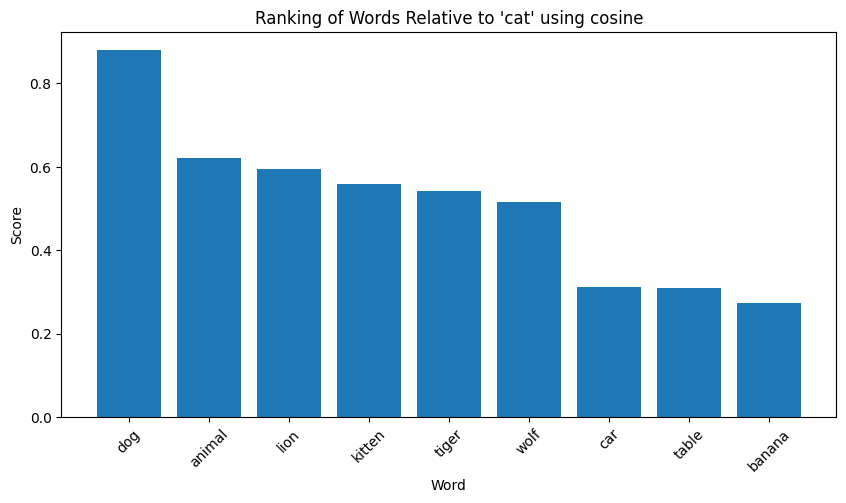

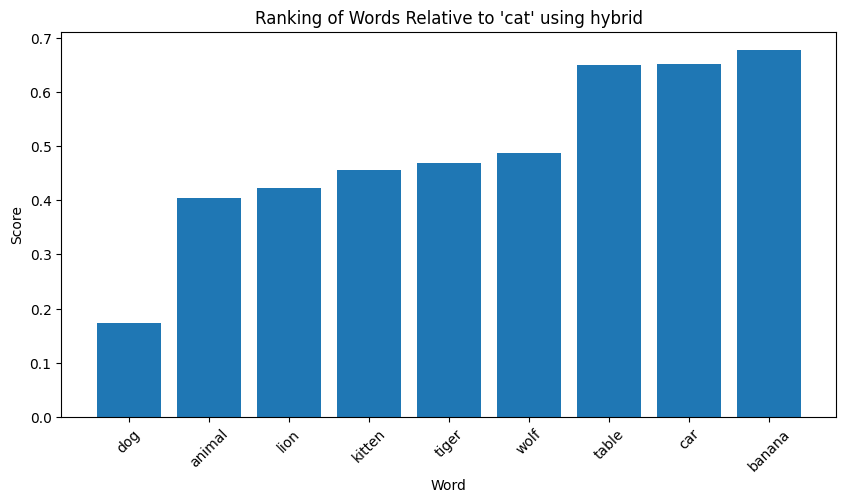

In [34]:
def plot_ranking(anchor_word, candidate_words, model, metric="cosine", alpha=0.6):
    ranked = rank_words_against_anchor(anchor_word, candidate_words, model, metric=metric, alpha=alpha)

    plt.figure(figsize=(10, 5))
    plt.bar(ranked["word"], ranked["score"])
    plt.title(f"Ranking of Words Relative to '{anchor_word}' using {metric}")
    plt.xlabel("Word")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.show()

plot_ranking(anchor, candidates, model, metric="cosine")
plot_ranking(anchor, candidates, model, metric="hybrid", alpha=0.6)

In [35]:
def build_metric_matrix(words, model, metric="cosine", alpha=0.6):
    n = len(words)
    mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            value, _, _ = compute_metric(words[i], words[j], model, metric=metric, alpha=alpha)
            mat[i, j] = np.nan if value is None else value

    return pd.DataFrame(mat, index=words, columns=words)

heatmap_words = ["cat", "dog", "lion", "table", "car", "banana", "king", "queen"]

cosine_matrix = build_metric_matrix(heatmap_words, model, metric="cosine")
hybrid_matrix = build_metric_matrix(heatmap_words, model, metric="hybrid", alpha=0.6)

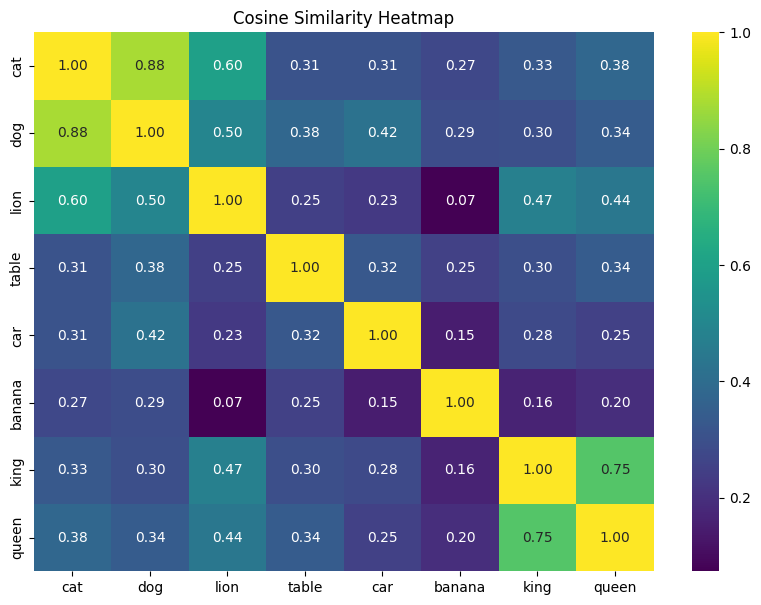

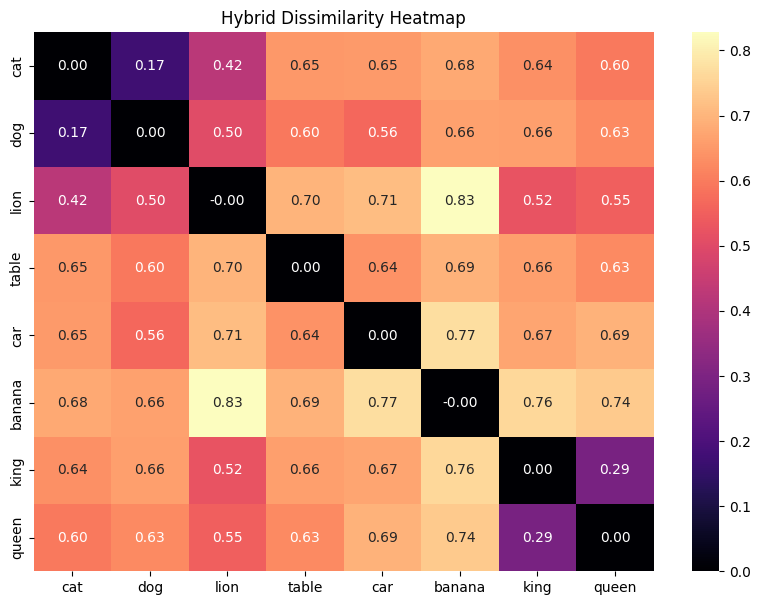

In [36]:
plt.figure(figsize=(10, 7))
sns.heatmap(cosine_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Cosine Similarity Heatmap")
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(hybrid_matrix, annot=True, cmap="magma", fmt=".2f")
plt.title("Hybrid Dissimilarity Heatmap")
plt.show()

## Discussion of Results

The model successfully generated embeddings for both **"coat"** and **"rope"** (two randomly chosen words), confirming that both words exist in the GloVe vocabulary. Each word was represented by a **100-dimensional vector**, demonstrating that the embedding model was correctly loaded and functioning.

The cosine similarity between **coat** and **rope** was **0.8798**, indicating that the vectors point in a similar direction in embedding space. The cosine dissimilarity was therefore low (**0.1202**). The Euclidean distance between the two vectors was **2.6811**, showing their absolute spatial separation. The custom **hybrid dissimilarity metric** produced a score of **0.1726**, combining both directional and distance-based differences.

The batch similarity results showed expected semantic relationships. For example, **cat–dog** had very high similarity, while **cat–table** was much lower. Similarly, **king–queen** and **car–automobile** showed strong relationships, demonstrating that the embeddings capture meaningful semantic structure.

The **PCA scatter plot** showed clear clustering of related words. Animal-related words (cat, dog, tiger, wolf) appeared close together, fruits (apple, banana) clustered together, and **king–queen** appeared near each other, reflecting their semantic similarity.

The **ranking plots** confirmed these relationships. Words closely related to **cat**, such as **dog**, **animal**, and **lion**, ranked highest in cosine similarity and lowest in hybrid dissimilarity, while unrelated words such as **table**, **car**, and **banana** ranked lower.

Finally, the **heatmap visualization** made it easy to compare similarities across multiple word pairs. Strong relationships such as **cat–dog** and **king–queen** appeared with higher similarity values, while unrelated pairs showed lower similarity.

Overall, the results demonstrate that the GloVe embeddings effectively capture semantic relationships between words, and the hybrid dissimilarity metric provides an additional way to measure both directional similarity and spatial distance between word vectors.